In [1]:
from singleCAM_IROS._pipeline_support import _handle_dirpaths

import numpy as np
import pandas as pd

from bloodmoon.io import simulation_files
from bloodmoon.mask import codedmask

import darksun as ds


skyfield = "GalacticCenter"

#mask_FITS = "wfm_mask_summer2021.fits"
#data_FITS = "galctr_rxte-sax_mask_summer2021_infdet_2-50keV_1ks"

mask_FITS = "wfm_mask_NTHT_20250725.fits"
data_FITS = "galctr_rxte-sax_mask_050_1040x17_infdet_2-50keV_1ks"

N_TEST = "singleCAM_iros_testing"

mask_path, simul_data, save_path = _handle_dirpaths(
    mask=mask_FITS,
    skyfield=skyfield,
    simul=data_FITS,
    run_name=N_TEST,
)

VIGNETTING = True
PSFY = False
UPX, UPY = 5, 1
wfm = codedmask(mask_path, UPX, UPY)

cam_a = "cam1a"
#cam_b = "cam1b"
dataset = 'detected'

filepaths = simulation_files(simul_data)
sdlA = ds.get_data(filepaths[cam_a][dataset])
catalogueA = ds.get_catalogue(filepaths[cam_a]['sources'])
#sdlB = ds.get_data(filepaths[cam_b][dataset])
#catalogueB = ds.get_catalogue(filepaths[cam_b]['sources'])

simul_sky_camA, _ = ds.load_sky(save_path + f"sky_SIMUL_CAM1A_TEST_{N_TEST}.fits")
#simul_sky_camB, _ = ds.load_sky(save_path + f"sky_SIMUL_CAM1B_TEST_{N_TEST}.fits")
log_camA, _ = ds.load_database(save_path + f"IROS_sources_database_TEST_{N_TEST}.fits")

pd.DataFrame(
    {
        log_camA.name: log_camA.log['ID'],
        f"{log_camA.name} SNR": log_camA.log['snr'],
    }
)

# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


,CAM1A,CAM1A SNR
0,scox1,749.152433
1,gx5-1,78.307137
2,gx349+2,60.073791
3,gx17+2,51.405661
4,gx9+1,46.722344
5,gx340+0,34.820543
6,groj1655-40,29.005915
7,gx3+1,26.115363
8,gx13+1,25.410615
9,x1820-303,24.144542


In [2]:
from typing import NamedTuple

from numpy.typing import NDArray

from bloodmoon.mask import CodedMaskCamera
from bloodmoon.optim import model_shadowgram


class Candidate(NamedTuple):
    """
    Source candidate main info container.

    Attributes:
        shift_x (float):
            Coded-mask camera local frame sky-coord along the x-axis [mm].
        shift_y (float):
            Coded-mask camera local frame sky-coord along the y-axis [mm].
        fluence (float):
            Observed candidate fluence [ph].
        snr (float):
            Candidate significance [adim].
    """
    shift_x: float
    shift_y: float
    fluence: float
    snr: float

def retrieve_detector(
    candidates: tuple[Candidate],
    camera: CodedMaskCamera,
    vignetting: bool,
    psfy: bool,
) -> NDArray:
    """Generates detector image from retrieved candidates."""
    img = np.zeros(camera.shape_detector)
    for (sx, sy, f, _) in candidates:
        shadowgram = model_shadowgram(
            camera=camera,
            shift_x=sx,
            shift_y=sy,
            vignetting=vignetting,
            psfy=psfy,
        )
        img += (f * shadowgram)
    return img


SMOOTHING_THRESHOLD = 10.0
_UP_TO = np.argwhere(np.array(log_camA.log['snr']) < SMOOTHING_THRESHOLD)[0, 0]

candidates = tuple(
    Candidate(sx, sy, f, signf) for sx, sy, f, signf in zip(
        log_camA.log['shift_x'][:_UP_TO],
        log_camA.log['shift_y'][:_UP_TO],
        log_camA.log['fluence'][:_UP_TO],
        log_camA.log['snr'][:_UP_TO],
    )
)

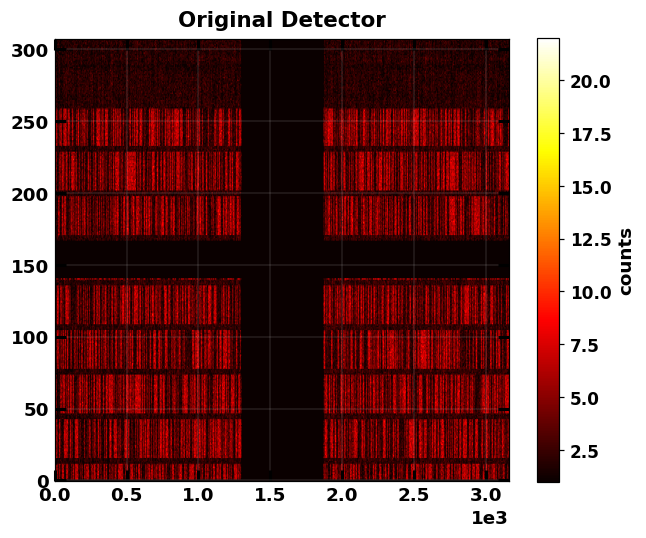

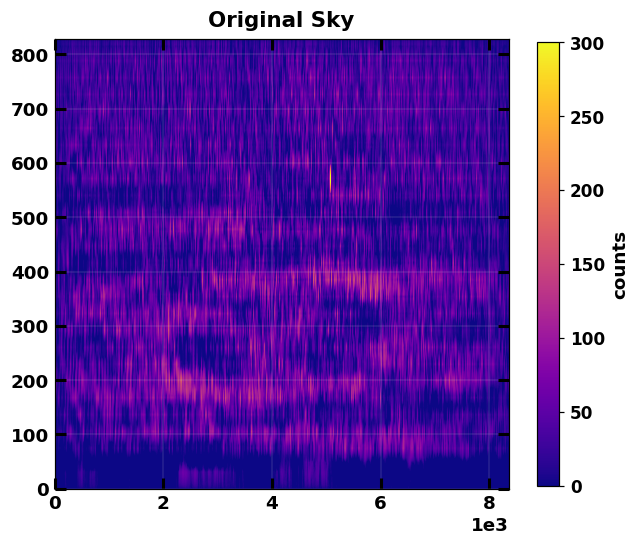

In [3]:
from bloodmoon.mask import count

detector = count(wfm, sdlA.DLdata)[0]
ASPECT = (wfm.specs['mask_deltay'] / UPY) / (wfm.specs['mask_deltax'] / UPX)

ds.image_plot(
    detector,
    title='Original Detector',
    cbarlabel='counts',
    cmap='hot',
    vmin=1,
    aspect=ASPECT,
)
ds.image_plot(
    np.sqrt(np.clip(simul_sky_camA, a_min=0, a_max=None)),
    title='Original Sky',
    cbarlabel='counts',
    cmap='plasma',
    vmax=3e2,
    aspect=ASPECT,
)

In [4]:
from bloodmoon.mask import decode, variance
from darksun.optim import bkg_smoothing

# residual detector
retrieved = retrieve_detector(
    candidates=candidates,
    camera=wfm,
    vignetting=VIGNETTING,
    psfy=PSFY,
)
resdet = detector - retrieved
res_sky = decode(wfm, resdet)

# smoothed residual detector
KERNEL_SIZE = {
    'y':11,
    'x': 7,
}
res_smoothed = bkg_smoothing(
    detector=resdet,
    camera=wfm,
    kernelsize_y=KERNEL_SIZE['y'],
    kernelsize_x=KERNEL_SIZE['x'],
)
res_smooth_sky = decode(wfm, res_smoothed)

# smoothed original detector
smoothed = detector - res_smoothed
smoothed_sky = decode(wfm, smoothed)

# profiles along X and Y axes
collapsed_det_x, collapsed_resdet_x, collapsed_res_smoothed_x, collapsed_smoothed_x = map(
    lambda x: np.sum(x, axis=0),
    (detector, resdet, res_smoothed, smoothed),
)

collapsed_det_y, collapsed_resdet_y, collapsed_res_smoothed_y, collapsed_smoothed_y = map(
    lambda x: np.sum(x, axis=1),
    (detector, resdet, res_smoothed, smoothed),
)

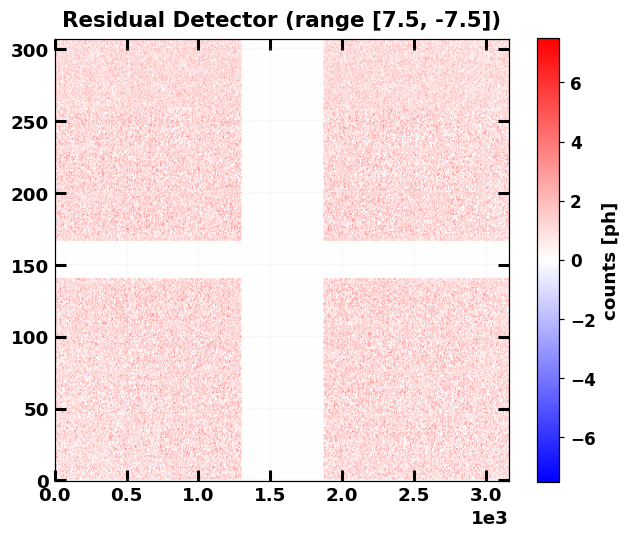

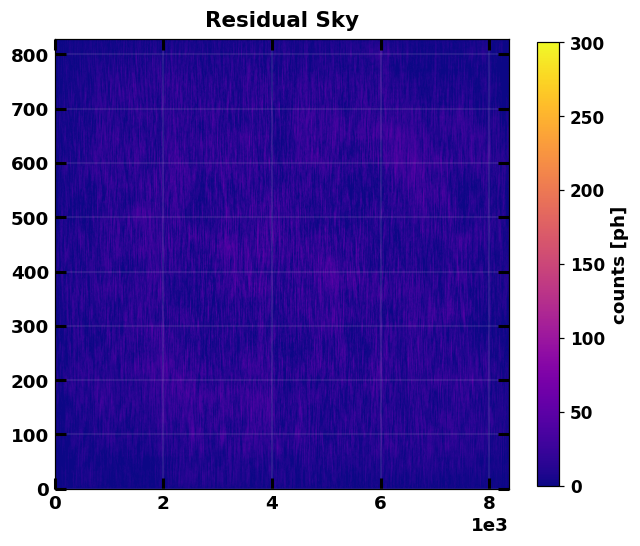

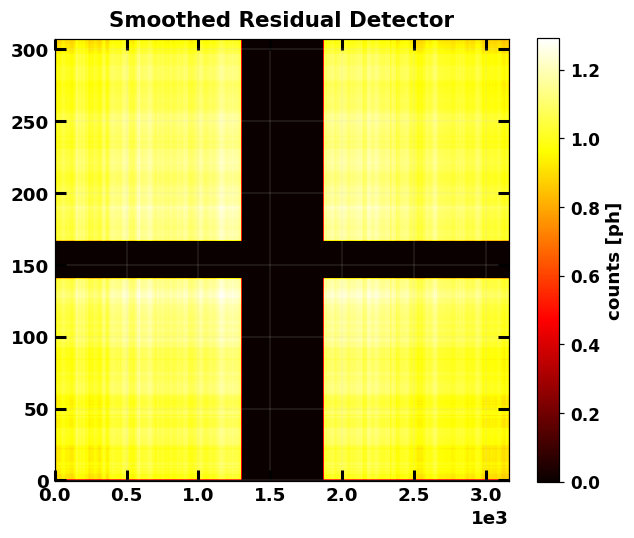

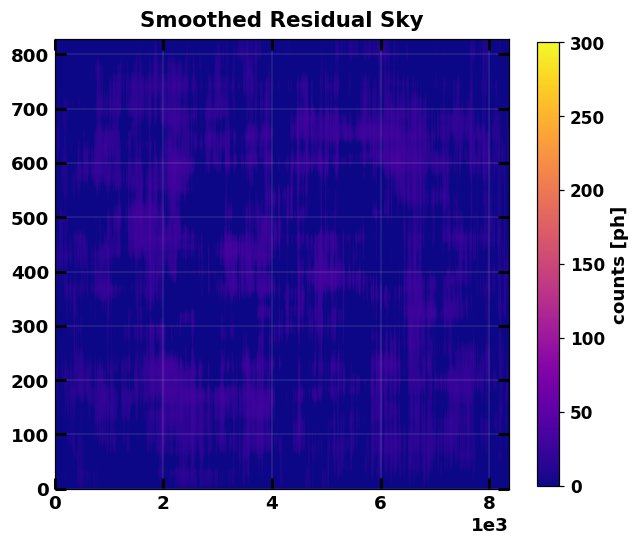

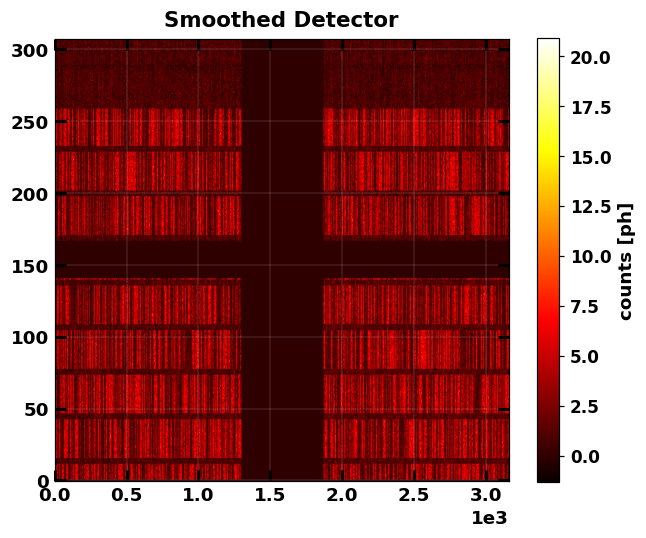

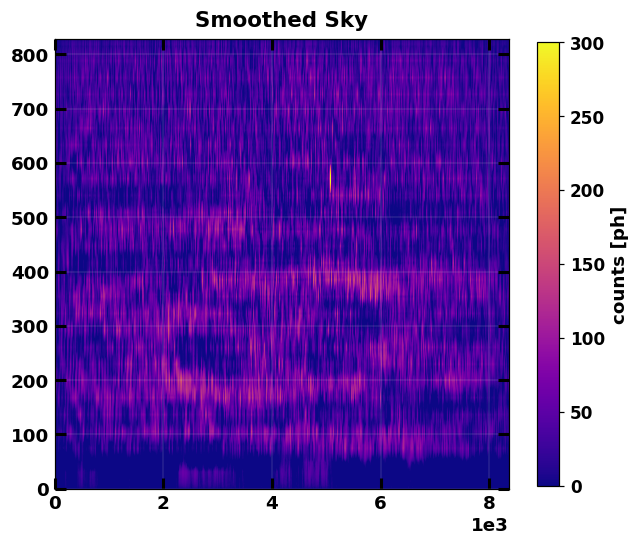

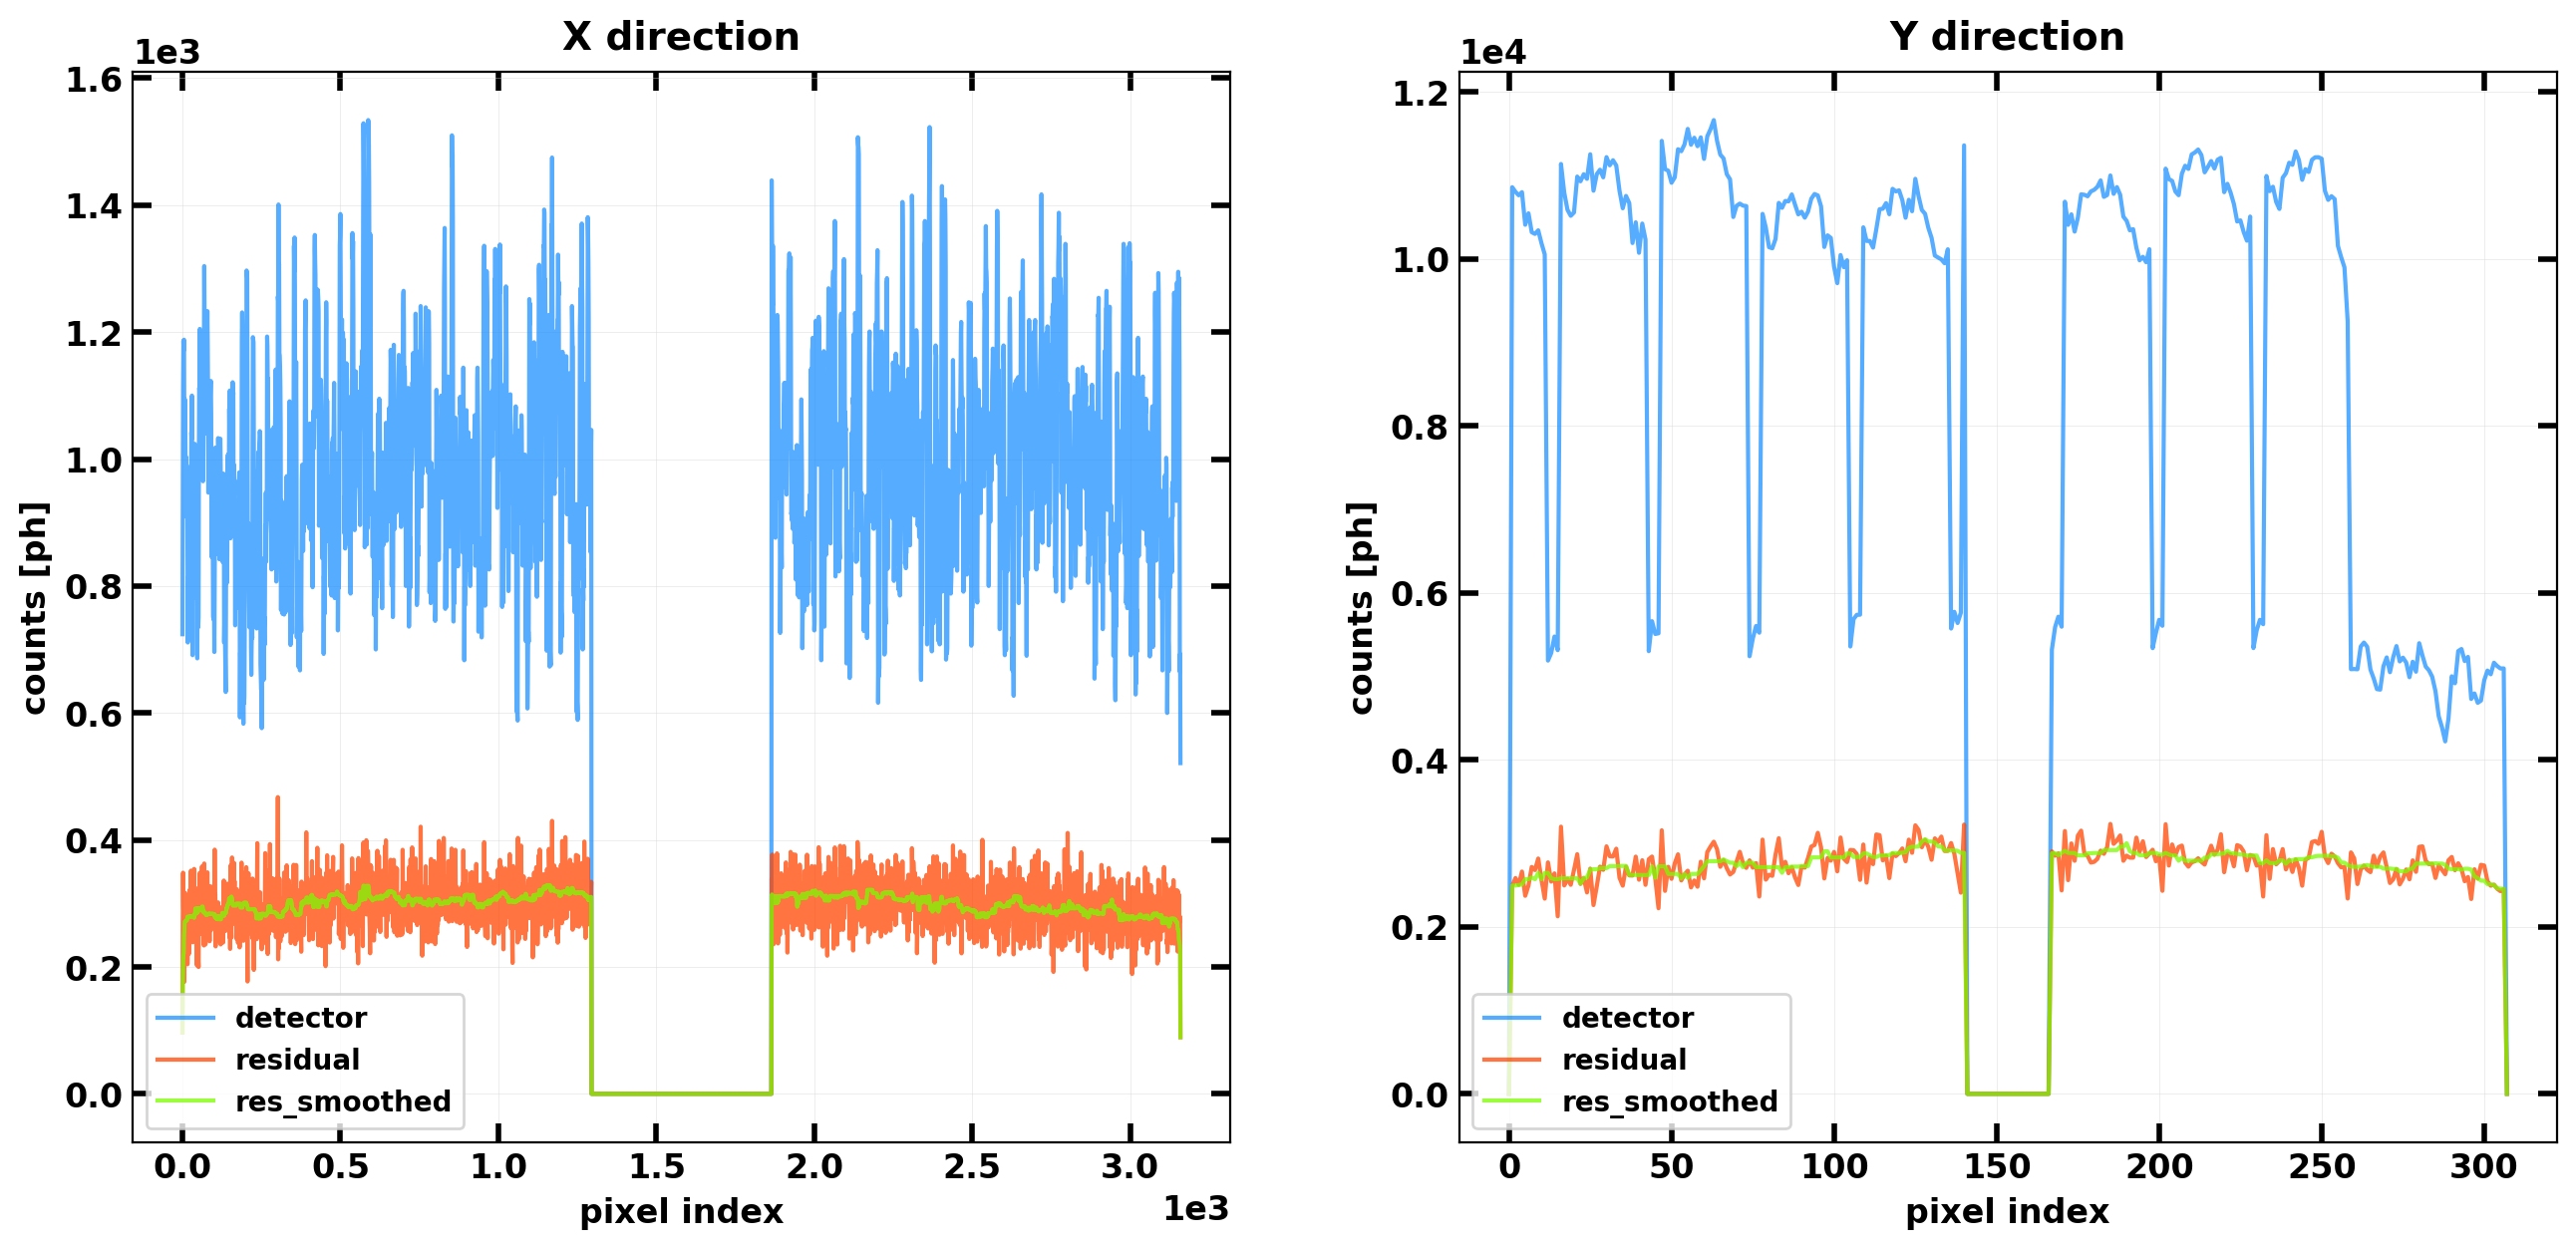

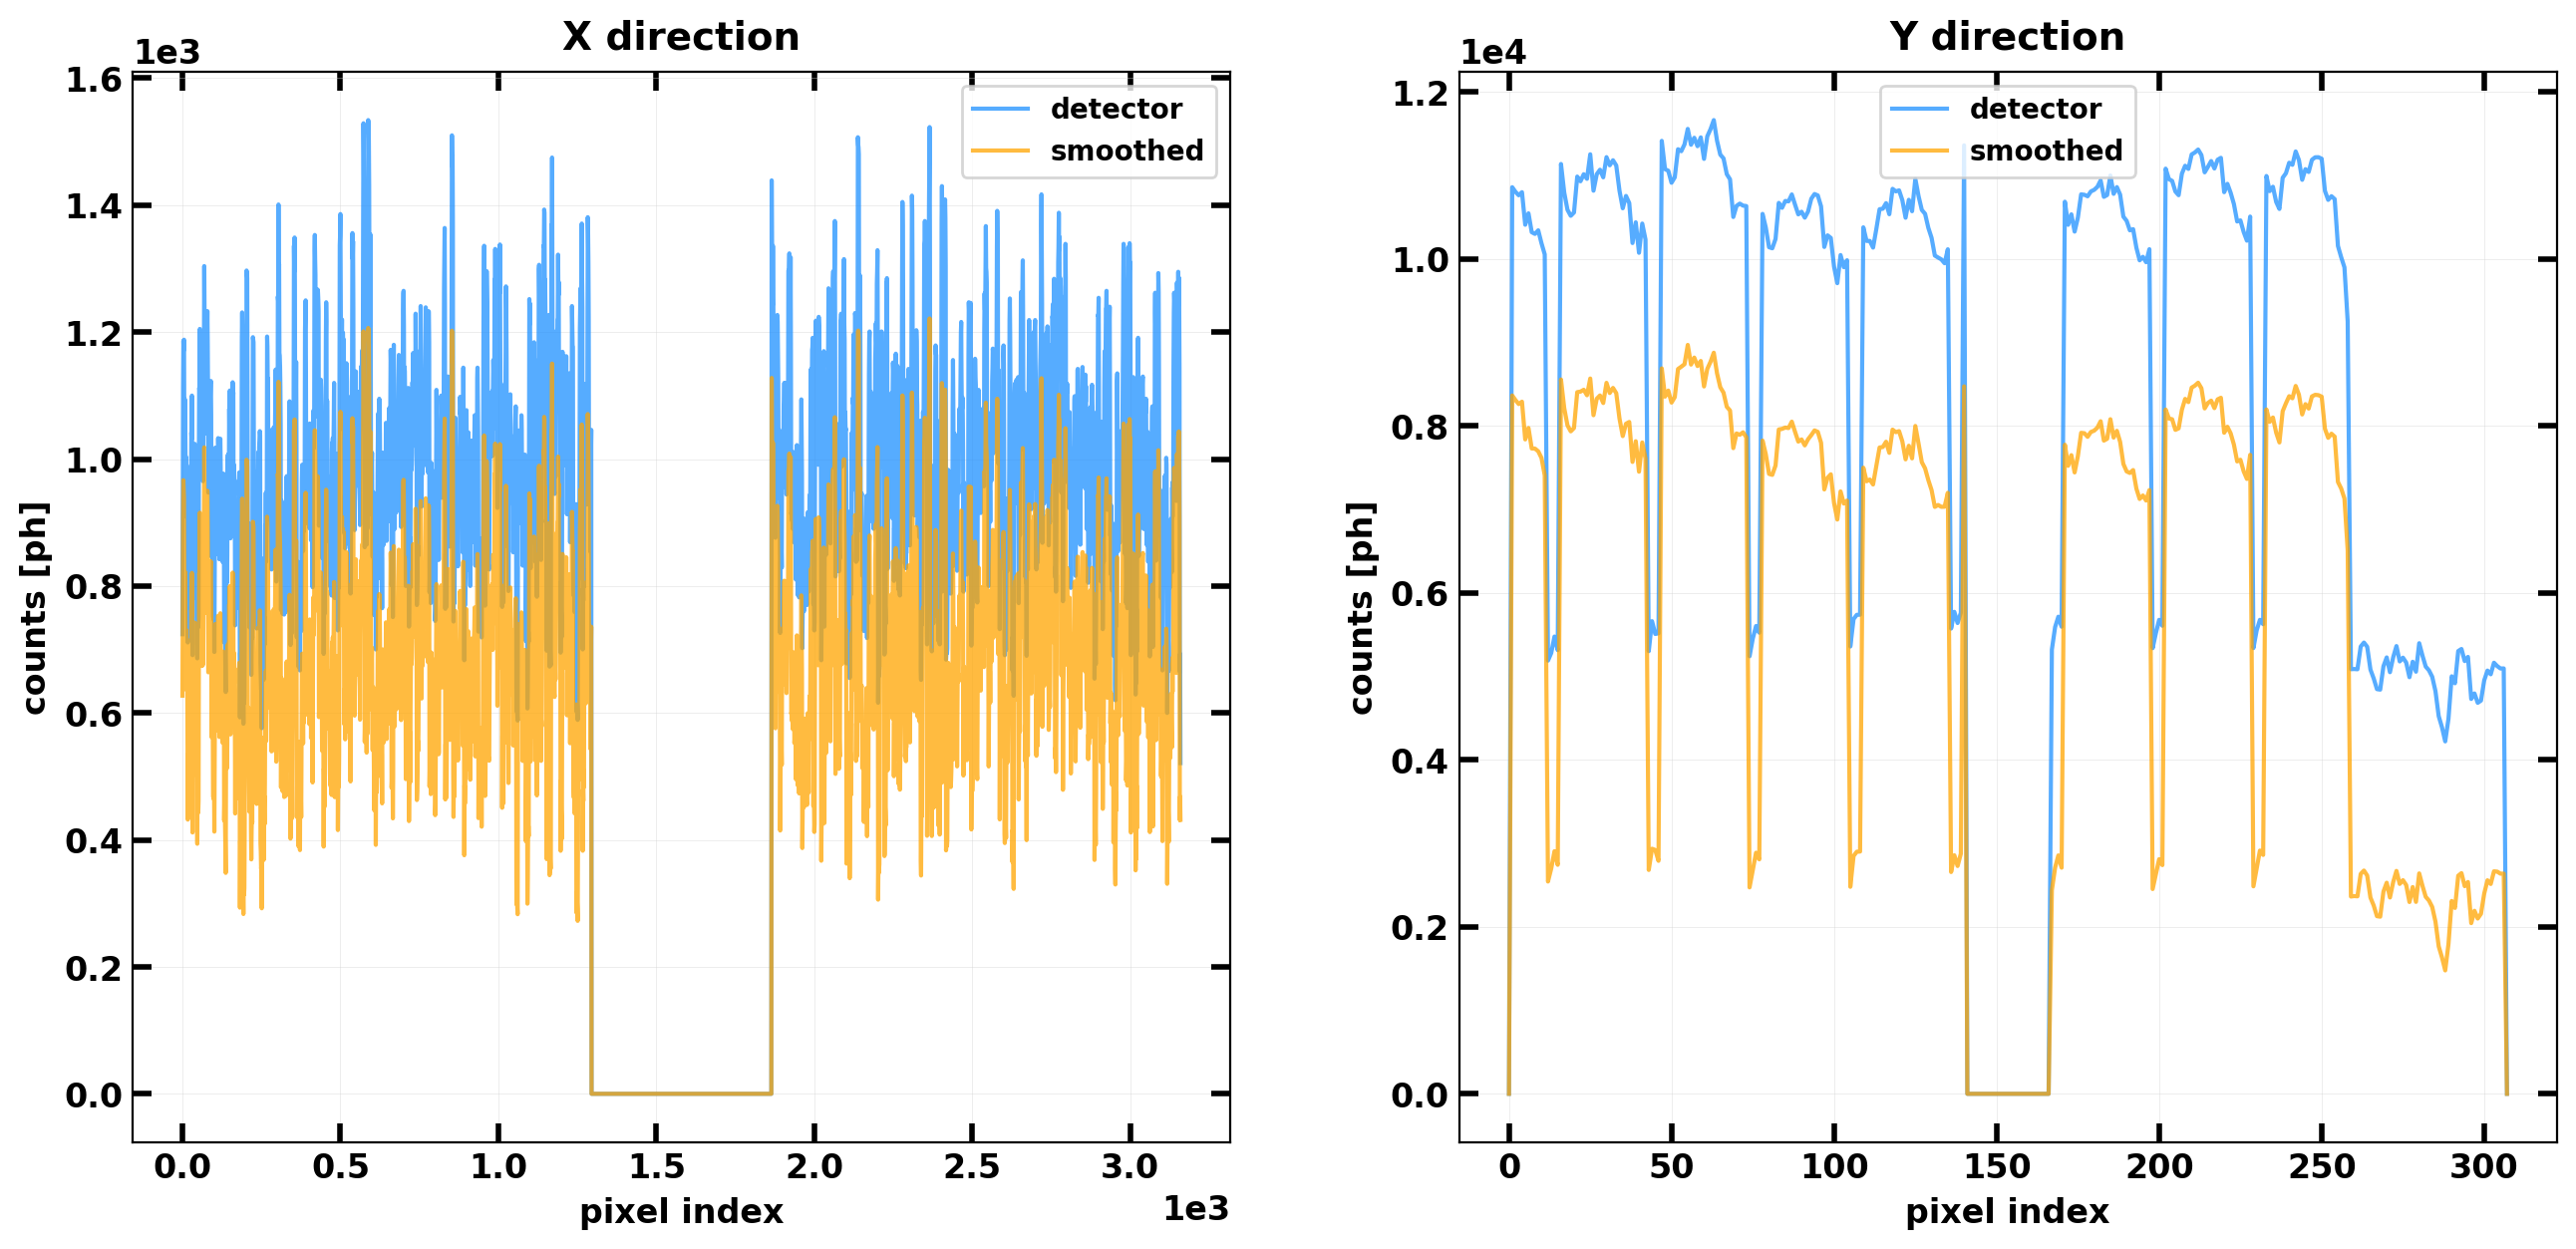

In [5]:
# plot residual detector and sky
LIM = 7.5
ds.image_plot(
    resdet,
    title='Residual Detector' + (f' (range [{LIM}, -{LIM}])' if LIM else ''),
    cbarlabel='counts [ph]',
    cmap='bwr',
    vmax=LIM if LIM else None,
    vmin=-LIM if LIM else None,
    aspect=ASPECT,
)
ds.image_plot(
    np.sqrt(np.clip(res_sky, a_min=0, a_max=None)),
    title='Residual Sky',
    cbarlabel='counts [ph]',
    cmap='plasma',
    vmax=3e2,
    aspect=ASPECT,
)

# plot smoothed residual detector and sky
LIM = 0
ds.image_plot(
    res_smoothed,
    title='Smoothed Residual Detector' + (f' (range [{LIM}, -{LIM}])' if LIM else ''),
    cbarlabel='counts [ph]',
    cmap='hot',
    vmax=LIM if LIM else None,
    vmin=-LIM if LIM else None,
    aspect=ASPECT,
)
ds.image_plot(
    np.sqrt(np.clip(res_smooth_sky, a_min=0, a_max=None)),
    title='Smoothed Residual Sky',
    cbarlabel='counts [ph]',
    cmap='plasma',
    vmax=3e2,
    aspect=ASPECT,
)

# plot smoothed original detector and sky
LIM = 0
ds.image_plot(
    smoothed,
    title='Smoothed Detector' + (f' (range [{LIM}, -{LIM}])' if LIM else ''),
    cbarlabel='counts [ph]',
    cmap='hot',
    vmax=LIM if LIM else None,
    vmin=-LIM if LIM else None,
    aspect=ASPECT,
)
ds.image_plot(
    np.sqrt(np.clip(smoothed_sky, a_min=0, a_max=None)),
    title='Smoothed Sky',
    cbarlabel='counts [ph]',
    cmap='plasma',
    vmax=3e2,
    aspect=ASPECT,
)

# plot detectors profiles
dmapx = ds.map4biplot(
    arrs=(
        collapsed_det_x, collapsed_resdet_x,
        collapsed_res_smoothed_x,
    ),
    title='X direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('detector', 'residual', 'res_smoothed'),
    color=('DodgerBlue', 'OrangeRed', 'LawnGreen')
)
dmapy = ds.map4biplot(
    arrs=(
        collapsed_det_y, collapsed_resdet_y,
        collapsed_res_smoothed_y,
    ),
    title='Y direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('detector', 'residual', 'res_smoothed'),
    color=('DodgerBlue', 'OrangeRed', 'LawnGreen')
)
ds.biplot(dmapx, dmapy)

dmapx_cfr = ds.map4biplot(
    arrs=(
        collapsed_det_x, collapsed_smoothed_x,
    ),
    title='X direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('detector', 'smoothed'),
    color=('DodgerBlue', 'Orange')
)
dmapy_cfr = ds.map4biplot(
    arrs=(
        collapsed_det_y, collapsed_smoothed_y,
    ),
    title='Y direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('detector', 'smoothed'),
    color=('DodgerBlue', 'Orange')
)
ds.biplot(dmapx_cfr, dmapy_cfr)

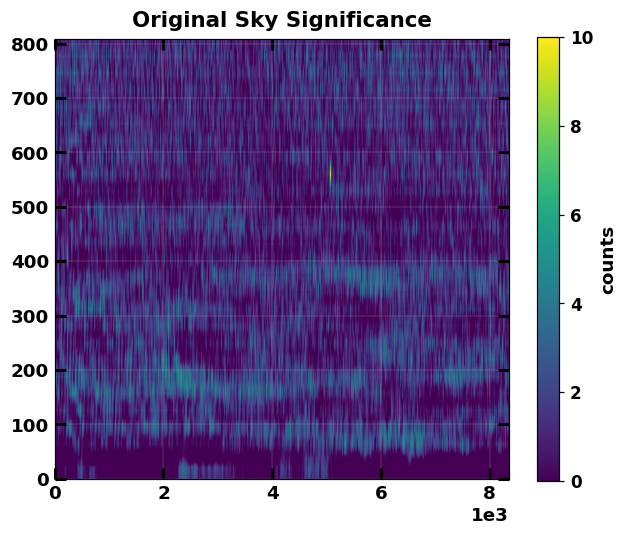

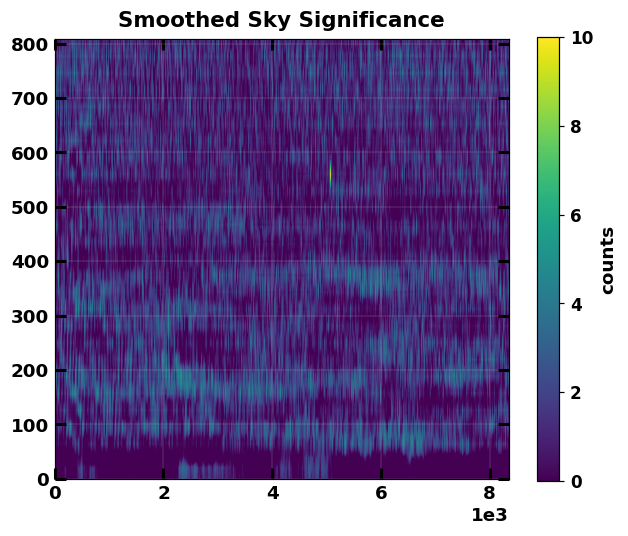

In [6]:
# compute significances
varmap = np.clip(variance(wfm, detector), a_min=1e-8, a_max=detector.sum())

YLIM, XLIM = 10, 5
significance = ds.unframe(simul_sky_camA / np.sqrt(varmap), YLIM, XLIM)
smoothed_significance = ds.unframe(smoothed_sky / np.sqrt(varmap), YLIM, XLIM)

res_significance = ds.unframe(res_sky / np.sqrt(varmap), YLIM, XLIM)
res_smoothed_significance = ds.unframe(res_smooth_sky / np.sqrt(varmap), YLIM, XLIM)

# plot significance maps
LIMmax = 10
ds.image_plot(
    np.sqrt(np.clip(significance, a_min=0, a_max=None)),
    title='Original Sky Significance',
    cbarlabel='counts',
    cmap='viridis',
    vmax=LIMmax,
    aspect=ASPECT,
)
ds.image_plot(
    np.sqrt(np.clip(smoothed_significance, a_min=0, a_max=None)),
    title='Smoothed Sky Significance',
    cbarlabel='counts',
    cmap='viridis',
    vmax=LIMmax,
    aspect=ASPECT,
)

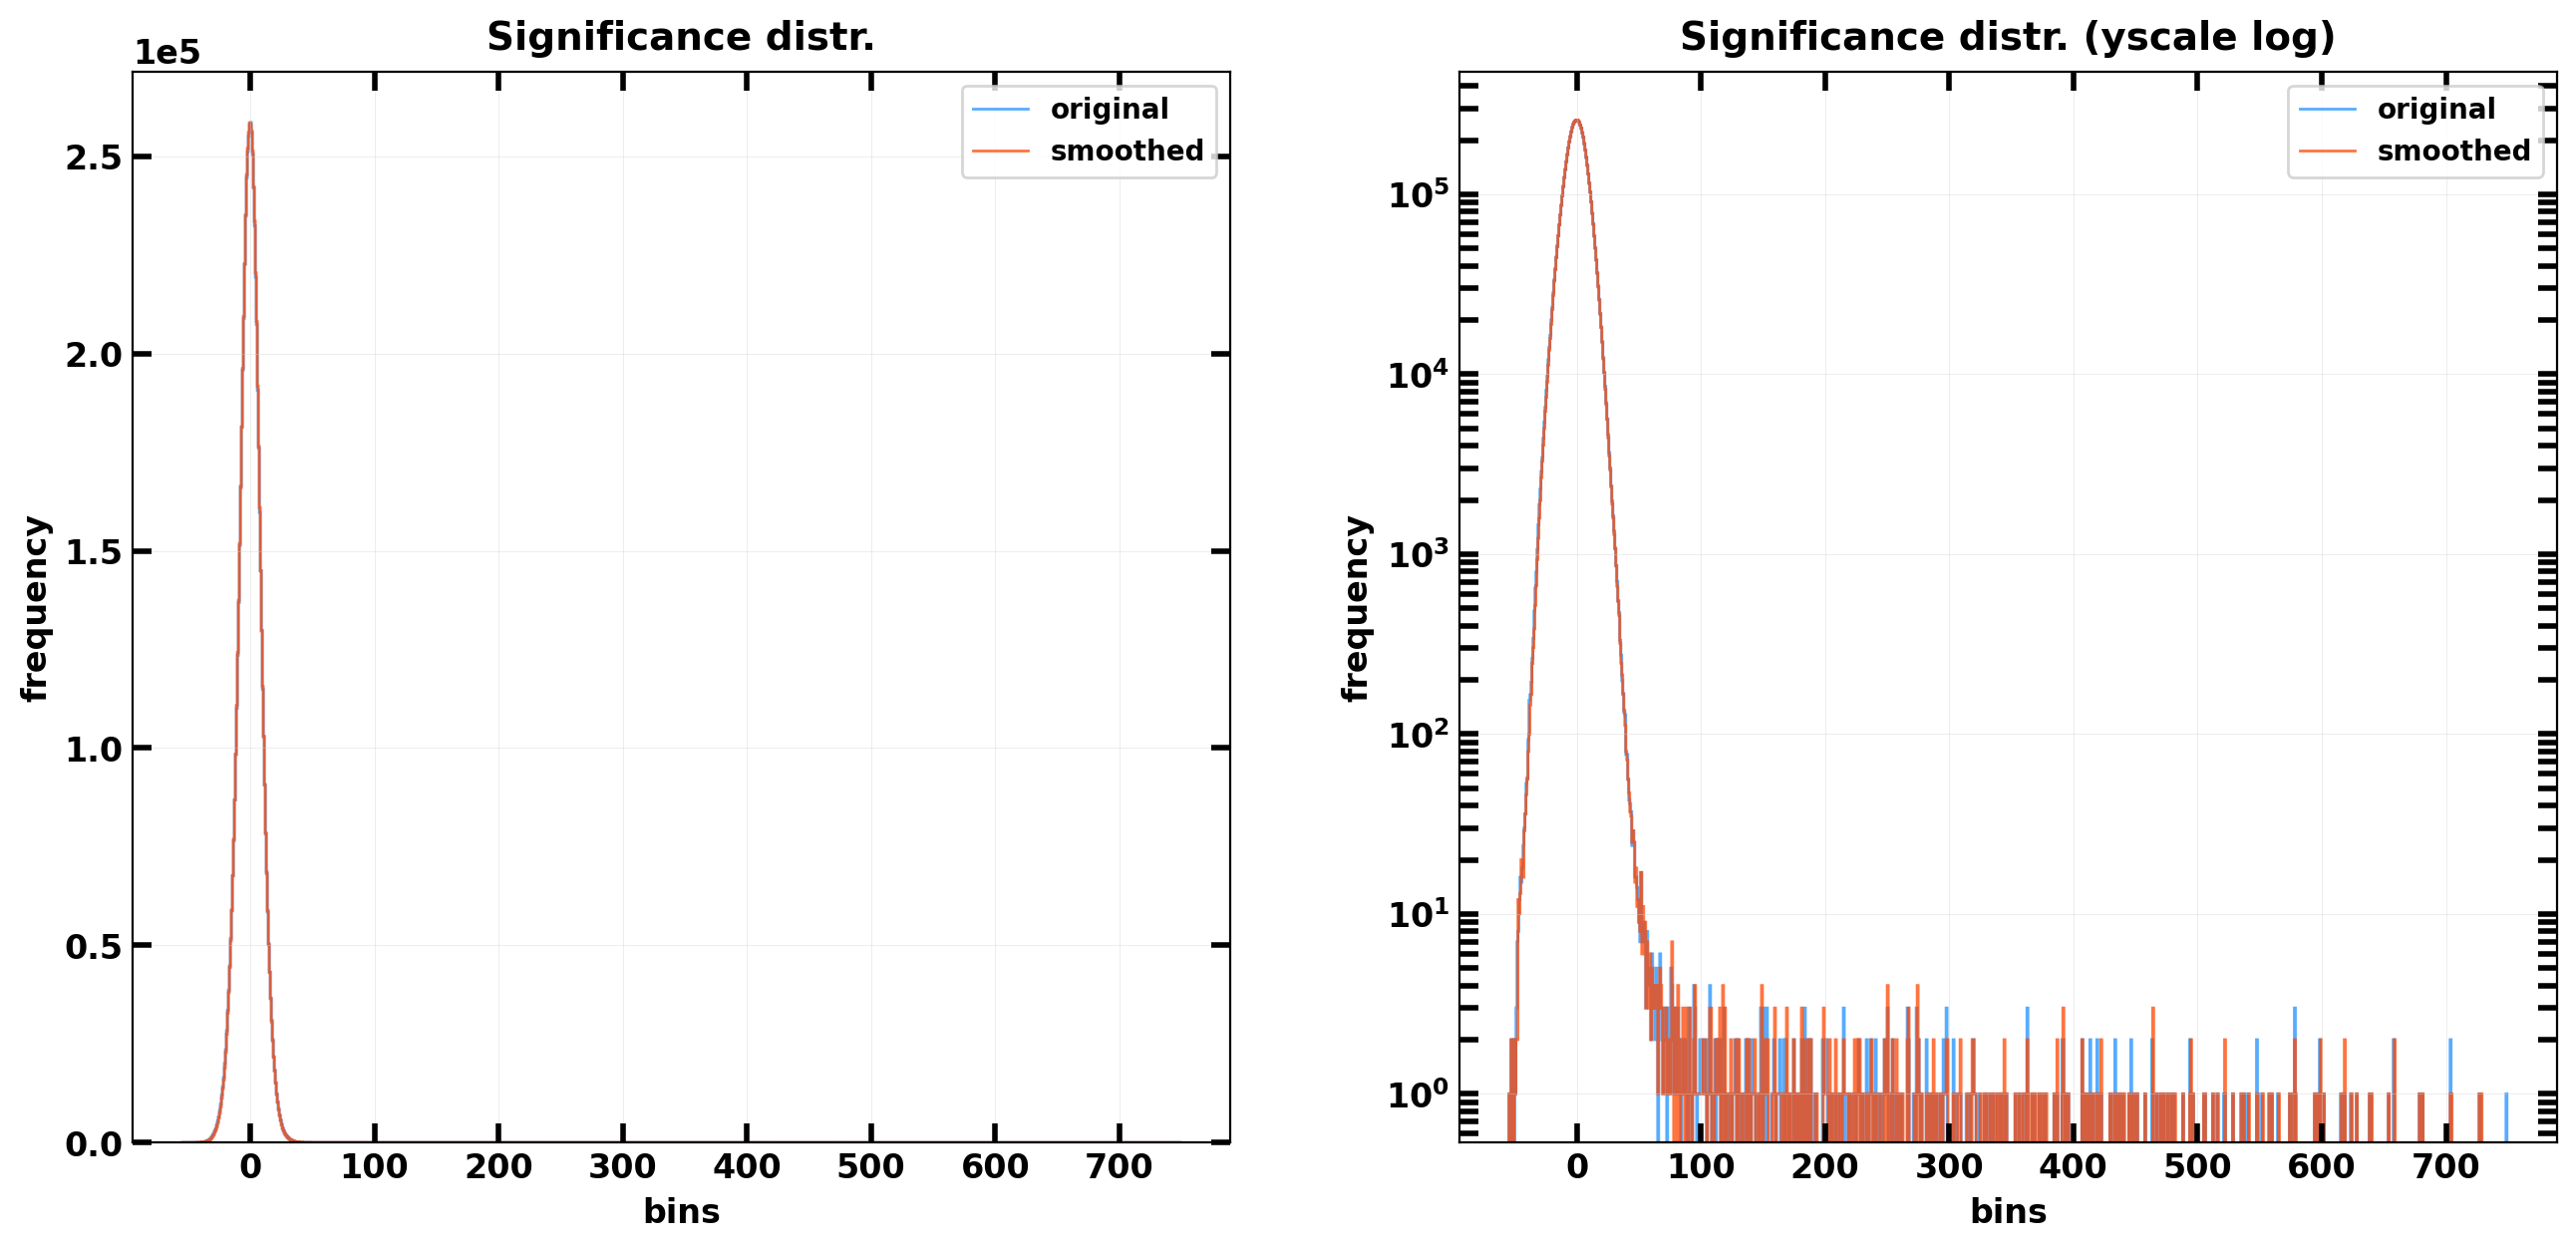

In [7]:
# check SNR distributions
def Gaussian(x: NDArray, x0: float = 0.0, sigma: float = 1.0) -> NDArray:
    """Returns a Gaussian distribution centered around `x0` and with std `sigma`."""
    return (
        1.0 / np.sqrt(2 * np.pi * np.square(sigma)) * np.exp(-np.square(x - x0) / (2 * np.square(sigma)))
    )

hist_signf, bins = np.histogram(significance, bins=1000, density=False)
hist_smoothed_signf, _ = np.histogram(smoothed_significance, bins=bins, density=False)
#bins = bins[:-1]


# plot distributions:
#   - sky and smoothed
dmap1_smooth = ds.map4biplot(
    arrs=(
        hist_signf, hist_smoothed_signf, #Gaussian(bins),
    ),
    title='Significance distr.',
    xlabel='bins',
    ylabel='frequency',
    labels=(
        'original', 'smoothed', #'std Gauss.',
    ),
    x=bins,
    style='stairs',
    color=('Dodgerblue', 'OrangeRed'),
)
dmap2_smooth = ds.map4biplot(
    arrs=(
        hist_signf, hist_smoothed_signf, #Gaussian(bins),
    ),
    title='Significance distr. (yscale log)',
    xlabel='bins',
    ylabel='frequency',
    labels=(
        'original', 'smoothed', #'std Gauss.',
    ),
    x=bins,
    style='stairs',
    color=('Dodgerblue', 'OrangeRed'),
    yscale='log',
)
ds.biplot(dmap1_smooth, dmap2_smooth)

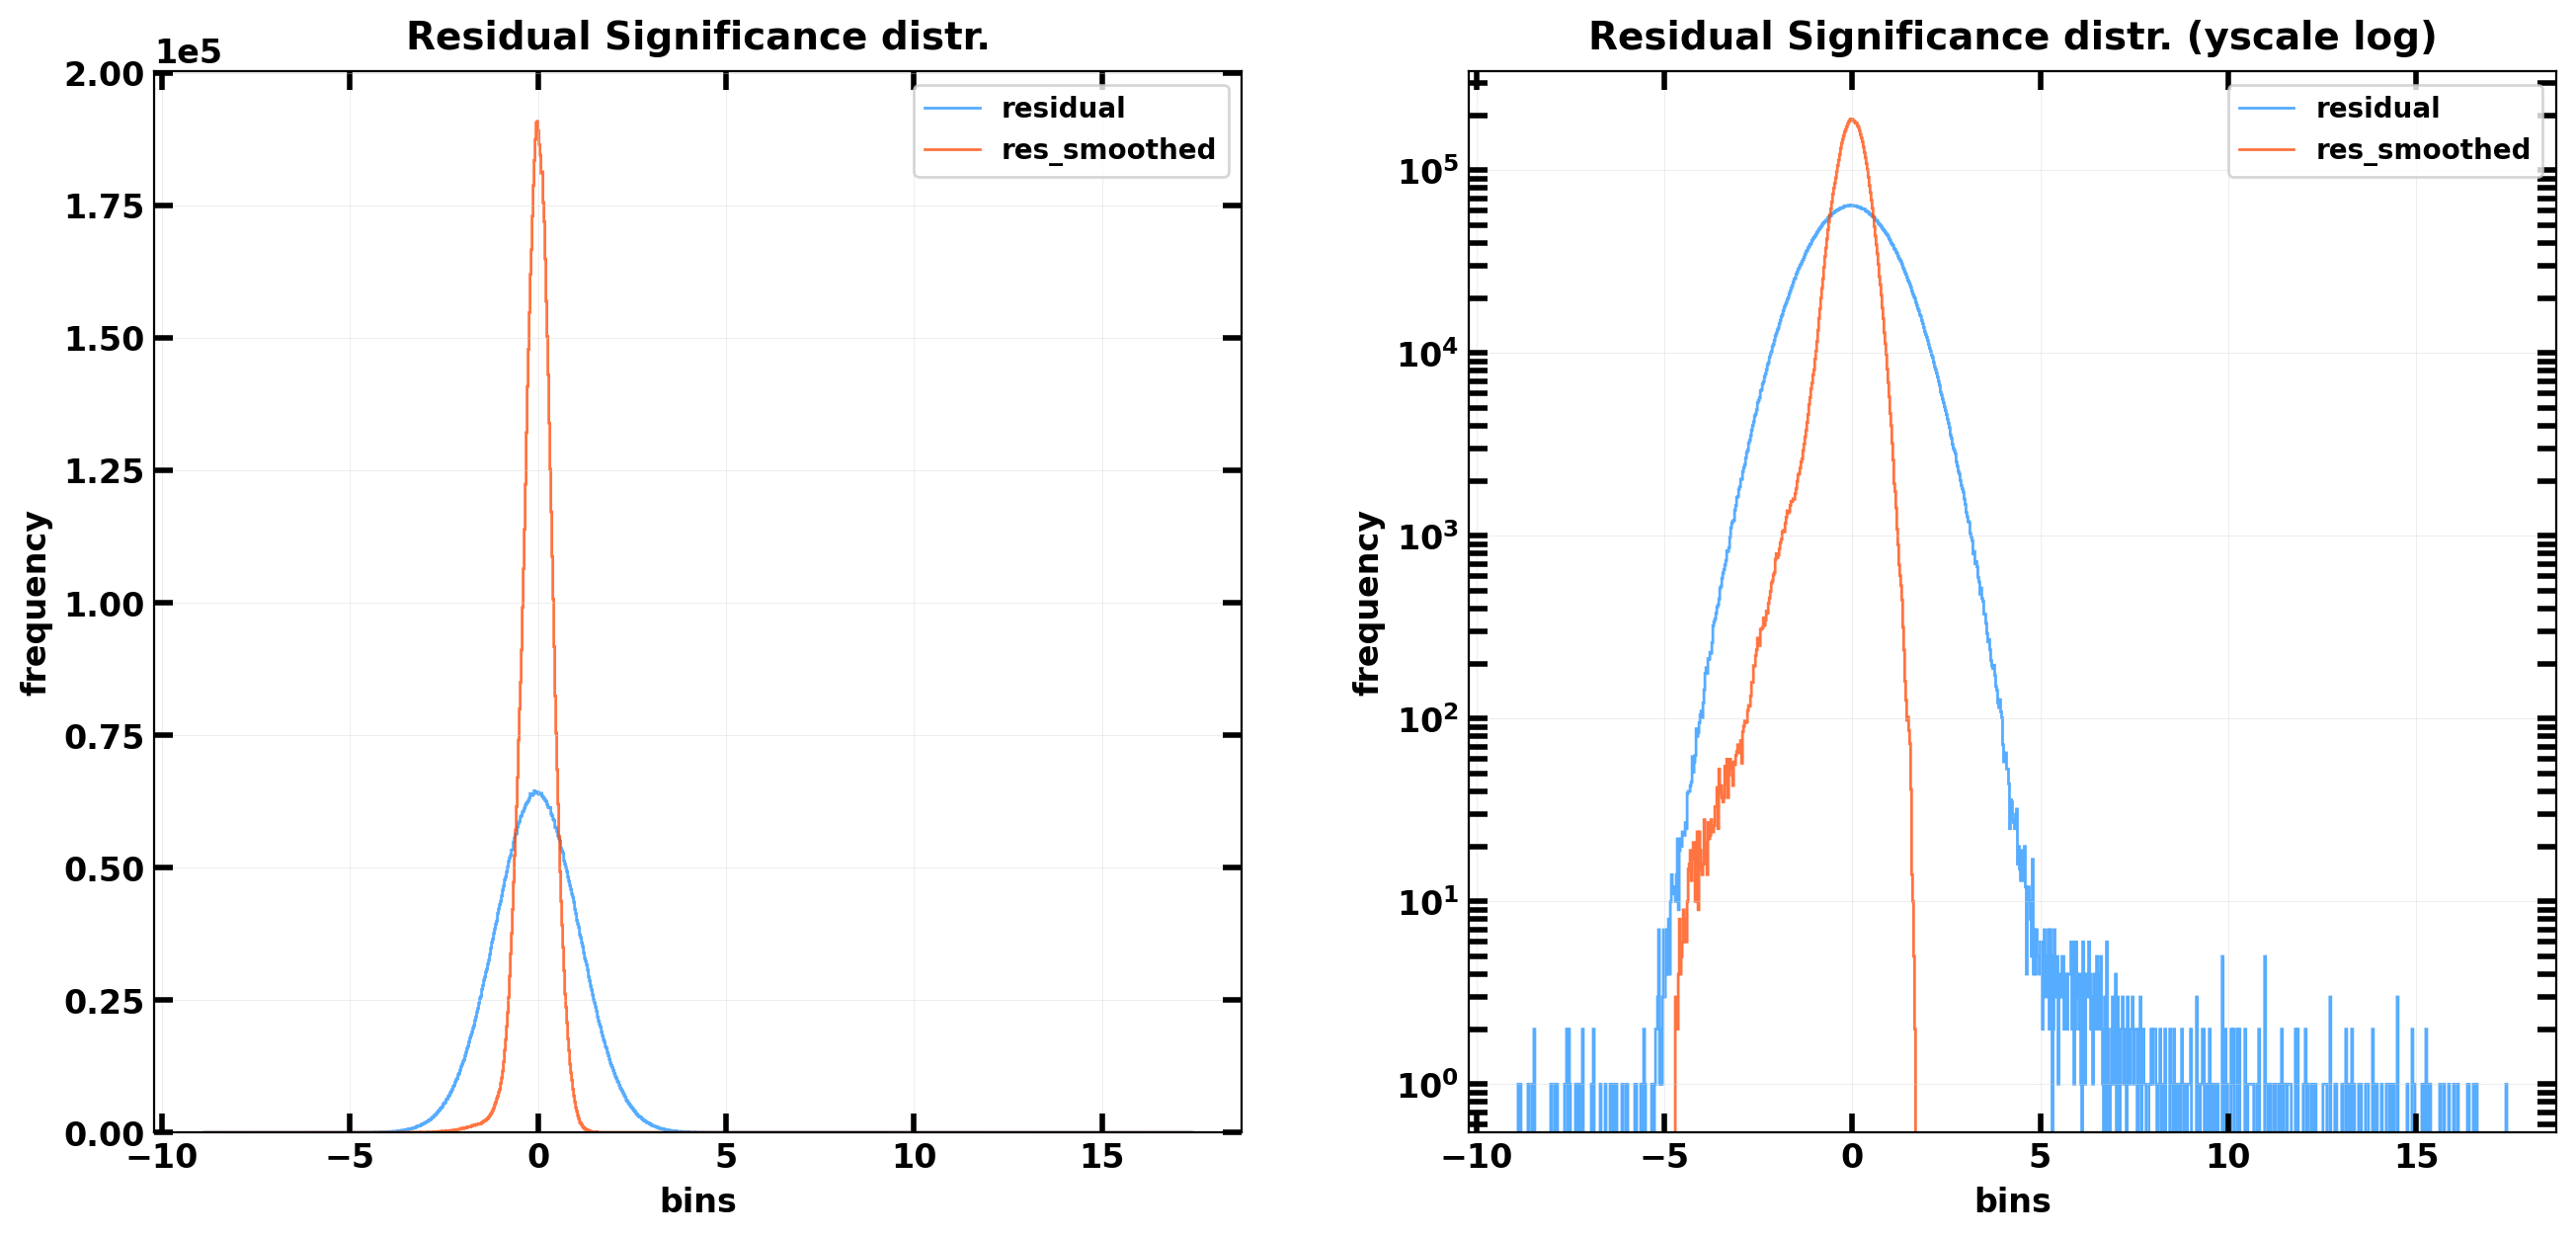

In [12]:
hist_res_signf, res_bins = np.histogram(res_significance, bins=1000, density=False)
hist_res_smoothed_signf, _ = np.histogram(res_smoothed_significance, bins=res_bins, density=False)


#   - residual sky and smoothed residual
dmap1_res_smooth = ds.map4biplot(
    arrs=(
        hist_res_signf, hist_res_smoothed_signf, #Gaussian(res_bins),
    ),
    title='Residual Significance distr.',
    xlabel='bins',
    ylabel='frequency',
    labels=(
        'residual', 'res_smoothed', #'std Gauss.',
    ),
    x=res_bins,
    style='stairs',
    color=('Dodgerblue', 'OrangeRed'),
)
dmap2_res_smooth = ds.map4biplot(
    arrs=(
        hist_res_signf, hist_res_smoothed_signf, #Gaussian(res_bins),
    ),
    title='Residual Significance distr. (yscale log)',
    xlabel='bins',
    ylabel='frequency',
    labels=(
        'residual', 'res_smoothed', #'std Gauss.',
    ),
    x=res_bins,
    style='stairs',
    color=('Dodgerblue', 'OrangeRed'),
    yscale='log',
)
ds.biplot(dmap1_res_smooth, dmap2_res_smooth)

In [ ]:
assert False

from darksun.show_trials import plot, image_plot

plot(dmapx)
plot(dmaps=(dmapx, dmapy), ncols=2)
image_plot(
    smoothed,
    title='Smoothed Detector',
    cbarlabel='counts',
    cmap='hot',
)

AssertionError: 

In [ ]:
assert False

import numpy as np
from scipy.signal import correlate

from bloodmoon.mask import codedmask, count

from darksun.data import get_data
from darksun.show import image_plot

basepath = '/home/edoardo/Datadisk/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations'
maskpath = f'{basepath}/wfm_mask_summer2021.fits'
datapath = f'{basepath}/IROSDummy/CXB_infdet_2-50keV_1ks_cam1a_detected.fits'

#basepath = '/mnt/d/PhD_AASS/Coding/Images_fits'
#maskpath = f'{basepath}/wfm_mask_summer2021.fits'
#datapath = f'{basepath}/IROSDummy/CXB_1ks_detected_2-50keV.fits'

UPX, UPY = 1, 1
wfm = codedmask(maskpath, UPX, UPY)
sdl = get_data(datapath)

detector = count(wfm, sdl.DLdata)[0]





from numpy.typing import NDArray
from bloodmoon.mask import CodedMaskCamera


def solid_angle_plate(
    x: float | NDArray,
    y: float | NDArray,
    width: float,
    height: float,
    distance: float,
) -> NDArray:
    r"""


    Args:
        x (float | NDArray):
            Observer position along the x-axis.
        y (float | NDArray):
            Observer position along the y-axis.
        width (float):
            Width of the rectangular plate.
        height (float):
            Height of the rectangular plate.
        distance (float):
            Distance between the plate and the observer.

    Returns:
        output (float | NDArray):
            Solid angle sky area on the plate seen by the observer.

    ## Notes
        - CFR with:
            * https://github.com/yuri-evangelista/CodedMasks/blob/26a5bb2fa08e37c645f85d55a3a1ef038fe7497d/mask_utils/imaging_utils.py#L58
            * https://vixra.org/pdf/2001.0603v2.pdf [Eq. 27, 34]
    """
    raise NotImplementedError


def camera_solid_angle(camera: CodedMaskCamera) -> NDArray:
    """
    Computes the sky solid angle profile seen by each active element
    of the coded-mask camera detector. The solid angle is computed
    by considering the instrument geometry.

    Args:
        camera (CodedMaskCamera):
            Camera instance containing the system geometry info.
    
    Returns:
        output (NDArray):
            2D array representing the solid angle profile.
    
    ## Notes:
        - CFR with:
            * https://github.com/yuri-evangelista/CodedMasks/blob/26a5bb2fa08e37c645f85d55a3a1ef038fe7497d/mask_utils/imaging_utils.py#L104
    """
    raise NotImplementedError


def variance(
    camera: CodedMaskCamera,
    detector: NDArray,
) -> NDArray:
    """
    Reconstructs balanced sky variance from detector image by using
    the expected photon counts, to neglect Poisson fluctuations.

    Args:
        camera (CodedMaskCamera):
            Camera instance containing mask and decoder patterns.
        detector (NDArray):
            2D array of detector counts.

    Returns:
        output (NDArray):
            Balanced variance map of the reconstructed sky image.
    
    ## Notes:
        - CFR with:
            * https://github.com/yuri-evangelista/CodedMasks/blob/26a5bb2fa08e37c645f85d55a3a1ef038fe7497d/mask_utils/imaging_utils.py#L134
    """
    # retrieve total detector counts and total active elements
    sum_det, sum_bulk = map(np.sum, (detector, camera.bulk))

    # compute expected counts for the detector image
    # - the expected counts array `Lambda` can be built as the product between
    #   a normalised matrix `Omega` representing the solid angle seen by each
    #   active pixel; and the total observed detector counts (i.e., `sum_det`)
    Omega = camera_solid_angle(camera)
    Lambda = sum_det * Omega / Omega.sum()

    # balanced variance components
    var = correlate(np.square(camera.decoder), Lambda, mode="full")
    bal = np.square(camera.balancing) * sum_det / np.square(sum_bulk)
    covar = correlate(camera.decoder, Lambda, mode="full")

    var_bal = (
        var + bal - 2 * covar * camera.balancing / sum_bulk
    )
    return var_bal